# AML Alert Prioritization — WIUT FinTech / AI in Finance Hackathon

**Team ID:** `5B7B633C`
**Evaluation Metric:** ROC-AUC

## Objective

The objective of this project is to estimate the probability that each AML alert in the hidden test set will be escalated.

Each alert is represented by:

- an alert identifier (`signal_id`);
- an alert date (`signal_sanasi`);
- a history of transactions associated with that alert;
- a binary escalation target (`eskalatsiya`) for training alerts.

The final prediction file contains one probability (`ehtimollik`) for every test alert.

## Approach

The modelling pipeline follows these steps:

1. Load and validate the raw alert and transaction datasets.
2. Remove transactions occurring after the corresponding alert date to prevent temporal leakage.
3. Perform exploratory analysis of the target, transaction activity, transaction types, and temporal behaviour.
4. Aggregate transaction histories into 53 alert-level behavioural features.
5. Sort training alerts chronologically and evaluate models using four forward-looking validation periods.
6. Train three complementary XGBoost configurations.
7. Blend their predictions using weights of 50% / 25% / 25%.
8. Train the selected ensemble on the complete training dataset.
9. Generate and validate the required competition CSV.

## Validation Strategy

Random cross-validation was avoided because the data contains a meaningful time dimension. Instead, four chronological validation periods were used so that every validation alert occurs strictly after the alerts used for training.

The selected full-history ensemble achieved a mean chronological validation ROC-AUC of approximately **0.6565**.

## Leakage Control

Transaction features are calculated only from transactions occurring on or before the corresponding alert date. Post-alert transactions are removed before feature engineering.

All feature tables are joined explicitly by `signal_id` and audited for ID uniqueness and row alignment before modelling.

In [1]:
# ============================================================
# WIUT HACKATHON — AML ALERT PRIORITIZATION
# Team: 5B7B633C
# Reproducible Submission Notebook
# ============================================================

import os
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

RANDOM_STATE = 42

print("=" * 80)
print("AML ALERT PRIORITIZATION")
print("Team: 5B7B633C")
print("=" * 80)

print("Python environment ready.")
print("Working directory:", os.getcwd())

AML ALERT PRIORITIZATION
Team: 5B7B633C
Python environment ready.
Working directory: C:\Users\khaki\PycharmProjects\aml-alert-prioritization\notebooks


In [2]:
# ============================================================
# CELL 2 — LOCATE AND LOAD RAW DATA
# ============================================================

from pathlib import Path

# Project root is one level above /notebooks
PROJECT_ROOT = Path.cwd().parent

print("Project root:", PROJECT_ROOT)


# ------------------------------------------------------------
# Expected competition files
# ------------------------------------------------------------

EXPECTED_FILES = [
    "train_signals.csv",
    "test_signals.csv",
    "train_transactions.parquet",
    "test_transactions.parquet",
]


# ------------------------------------------------------------
# Search project recursively
# ------------------------------------------------------------

found_files = {}

for filename in EXPECTED_FILES:

    matches = list(
        PROJECT_ROOT.rglob(filename)
    )

    if len(matches) == 0:
        raise FileNotFoundError(
            f"Could not find {filename}"
        )

    if len(matches) > 1:
        print(
            f"WARNING: Multiple copies of {filename} found:"
        )

        for path in matches:
            print("  ", path)

    found_files[filename] = matches[0]


print("\nFiles found:")

for filename, path in found_files.items():
    print(f"{filename}: {path}")


# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------

train_signals = pd.read_csv(
    found_files["train_signals.csv"]
)

test_signals = pd.read_csv(
    found_files["test_signals.csv"]
)

train_transactions = pd.read_parquet(
    found_files["train_transactions.parquet"]
)

test_transactions = pd.read_parquet(
    found_files["test_transactions.parquet"]
)


# ------------------------------------------------------------
# Basic confirmation
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("RAW DATA LOADED")
print("=" * 80)

print(
    "train_signals:",
    train_signals.shape
)

print(
    "test_signals:",
    test_signals.shape
)

print(
    "train_transactions:",
    train_transactions.shape
)

print(
    "test_transactions:",
    test_transactions.shape
)


print("\nTrain signal columns:")
print(
    train_signals.columns.tolist()
)

print("\nTransaction columns:")
print(
    train_transactions.columns.tolist()
)

Project root: C:\Users\khaki\PycharmProjects\aml-alert-prioritization

Files found:
train_signals.csv: C:\Users\khaki\PycharmProjects\aml-alert-prioritization\data\train_signals.csv
test_signals.csv: C:\Users\khaki\PycharmProjects\aml-alert-prioritization\data\test_signals.csv
train_transactions.parquet: C:\Users\khaki\PycharmProjects\aml-alert-prioritization\data\train_transactions.parquet
test_transactions.parquet: C:\Users\khaki\PycharmProjects\aml-alert-prioritization\data\test_transactions.parquet

RAW DATA LOADED
train_signals: (14000, 3)
test_signals: (6000, 2)
train_transactions: (6987663, 5)
test_transactions: (3027575, 5)

Train signal columns:
['signal_id', 'signal_sanasi', 'eskalatsiya']

Transaction columns:
['signal_id', 'tranzaksiya_vaqti', 'kirim_chiqim', 'tranzaksiya_turi', 'miqdor_indeksi']


In [3]:
# ============================================================
# CELL 3 — RAW DATA INTEGRITY CHECK
# ============================================================

# ------------------------------------------------------------
# Convert date columns
# ------------------------------------------------------------

train_signals["signal_sanasi"] = pd.to_datetime(
    train_signals["signal_sanasi"]
)

test_signals["signal_sanasi"] = pd.to_datetime(
    test_signals["signal_sanasi"]
)

train_transactions["tranzaksiya_vaqti"] = pd.to_datetime(
    train_transactions["tranzaksiya_vaqti"]
)

test_transactions["tranzaksiya_vaqti"] = pd.to_datetime(
    test_transactions["tranzaksiya_vaqti"]
)


# ------------------------------------------------------------
# Signal ID checks
# ------------------------------------------------------------

print("=" * 80)
print("SIGNAL ID CHECKS")
print("=" * 80)

print(
    "Train unique IDs:",
    train_signals["signal_id"].nunique(),
    "/",
    len(train_signals)
)

print(
    "Test unique IDs:",
    test_signals["signal_id"].nunique(),
    "/",
    len(test_signals)
)

overlap = set(
    train_signals["signal_id"]
) & set(
    test_signals["signal_id"]
)

print(
    "Train/Test ID overlap:",
    len(overlap)
)


assert train_signals["signal_id"].is_unique
assert test_signals["signal_id"].is_unique
assert len(overlap) == 0


# ------------------------------------------------------------
# Target checks
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TARGET CHECKS")
print("=" * 80)

print(
    train_signals["eskalatsiya"]
    .value_counts()
    .sort_index()
)

print(
    "\nPositive rate:",
    train_signals["eskalatsiya"].mean()
)

assert set(
    train_signals["eskalatsiya"].unique()
) == {0, 1}


# ------------------------------------------------------------
# Date checks
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("DATE RANGES")
print("=" * 80)

print(
    "Train signals:",
    train_signals["signal_sanasi"].min().date(),
    "to",
    train_signals["signal_sanasi"].max().date()
)

print(
    "Test signals:",
    test_signals["signal_sanasi"].min().date(),
    "to",
    test_signals["signal_sanasi"].max().date()
)

print(
    "Train transactions:",
    train_transactions["tranzaksiya_vaqti"].min(),
    "to",
    train_transactions["tranzaksiya_vaqti"].max()
)

print(
    "Test transactions:",
    test_transactions["tranzaksiya_vaqti"].min(),
    "to",
    test_transactions["tranzaksiya_vaqti"].max()
)


# ------------------------------------------------------------
# Transaction relationship checks
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TRANSACTION RELATIONSHIP CHECKS")
print("=" * 80)

train_tx_ids = set(
    train_transactions["signal_id"].unique()
)

test_tx_ids = set(
    test_transactions["signal_id"].unique()
)

train_signal_ids = set(
    train_signals["signal_id"]
)

test_signal_ids = set(
    test_signals["signal_id"]
)


print(
    "Train alerts represented in transactions:",
    len(train_tx_ids & train_signal_ids),
    "/",
    len(train_signal_ids)
)

print(
    "Test alerts represented in transactions:",
    len(test_tx_ids & test_signal_ids),
    "/",
    len(test_signal_ids)
)

print(
    "Unknown train transaction IDs:",
    len(train_tx_ids - train_signal_ids)
)

print(
    "Unknown test transaction IDs:",
    len(test_tx_ids - test_signal_ids)
)


# ------------------------------------------------------------
# Missing-value overview
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("MISSING VALUES")
print("=" * 80)

print("\ntrain_signals:")
print(
    train_signals.isna().sum().to_string()
)

print("\ntest_signals:")
print(
    test_signals.isna().sum().to_string()
)

print("\ntrain_transactions:")
print(
    train_transactions.isna().sum().to_string()
)

print("\ntest_transactions:")
print(
    test_transactions.isna().sum().to_string()
)


# ------------------------------------------------------------
# Category checks
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TRANSACTION CATEGORIES")
print("=" * 80)

print("\nkirim_chiqim:")
print(
    train_transactions["kirim_chiqim"]
    .value_counts()
    .to_string()
)

print("\ntranzaksiya_turi:")
print(
    train_transactions["tranzaksiya_turi"]
    .value_counts()
    .to_string()
)


print("\n" + "=" * 80)
print("RAW DATA INTEGRITY CHECK COMPLETE")
print("=" * 80)

SIGNAL ID CHECKS
Train unique IDs: 14000 / 14000
Test unique IDs: 6000 / 6000
Train/Test ID overlap: 0

TARGET CHECKS
eskalatsiya
0    11595
1     2405
Name: count, dtype: int64

Positive rate: 0.1717857142857143

DATE RANGES
Train signals: 2025-01-01 to 2026-12-31
Test signals: 2025-01-01 to 2026-12-31
Train transactions: 2024-07-05 00:31:36 to 2026-12-31 00:00:00
Test transactions: 2024-07-05 00:42:26 to 2026-12-31 00:00:00

TRANSACTION RELATIONSHIP CHECKS
Train alerts represented in transactions: 14000 / 14000
Test alerts represented in transactions: 6000 / 6000
Unknown train transaction IDs: 0
Unknown test transaction IDs: 0

MISSING VALUES

train_signals:
signal_id        0
signal_sanasi    0
eskalatsiya      0

test_signals:
signal_id        0
signal_sanasi    0

train_transactions:
signal_id            0
tranzaksiya_vaqti    0
kirim_chiqim         0
tranzaksiya_turi     0
miqdor_indeksi       0

test_transactions:
signal_id            0
tranzaksiya_vaqti    0
kirim_chiqim       

In [4]:
# ============================================================
# CELL 4 — LEAKAGE-SAFE TRANSACTION HISTORY
# ============================================================

def create_safe_transaction_history(
    signals,
    transactions,
    name
):

    signal_dates = signals[
        [
            "signal_id",
            "signal_sanasi"
        ]
    ].copy()


    tx = transactions.merge(
        signal_dates,
        on="signal_id",
        how="left",
        validate="many_to_one"
    )


    # Transaction must exist on or before the alert timestamp/date.
    valid_mask = (
        tx["tranzaksiya_vaqti"]
        <=
        tx["signal_sanasi"]
    )


    future_mask = ~valid_mask


    removed_rows = int(
        future_mask.sum()
    )


    affected_signals = int(
        tx.loc[
            future_mask,
            "signal_id"
        ].nunique()
    )


    clean = (
        tx.loc[
            valid_mask
        ]
        .drop(
            columns="signal_sanasi"
        )
        .copy()
    )


    print(f"\n{name}")
    print("-" * 60)

    print(
        "Original transactions:",
        len(transactions)
    )

    print(
        "Removed post-alert transactions:",
        removed_rows
    )

    print(
        "Affected signals:",
        affected_signals
    )

    print(
        "Remaining transactions:",
        len(clean)
    )


    return clean


print("=" * 80)
print("CREATING LEAKAGE-SAFE TRANSACTION HISTORY")
print("=" * 80)


tx_history = create_safe_transaction_history(
    train_signals,
    train_transactions,
    "TRAIN"
)


test_tx_history = create_safe_transaction_history(
    test_signals,
    test_transactions,
    "TEST"
)


# ------------------------------------------------------------
# Verify that no post-alert transactions remain
# ------------------------------------------------------------

def verify_safe_history(
    signals,
    transactions,
    name
):

    check = transactions.merge(
        signals[
            [
                "signal_id",
                "signal_sanasi"
            ]
        ],
        on="signal_id",
        how="left",
        validate="many_to_one"
    )


    future_count = int(
        (
            check["tranzaksiya_vaqti"]
            >
            check["signal_sanasi"]
        ).sum()
    )


    print(
        f"{name} remaining post-alert transactions:",
        future_count
    )


    assert future_count == 0


print("\n" + "=" * 80)
print("SAFETY VERIFICATION")
print("=" * 80)


verify_safe_history(
    train_signals,
    tx_history,
    "TRAIN"
)


verify_safe_history(
    test_signals,
    test_tx_history,
    "TEST"
)


# Expected from our verified experimental pipeline
assert len(tx_history) == 6_986_823
assert len(test_tx_history) == 3_027_524


print("\nFinal safe shapes:")

print(
    "tx_history:",
    tx_history.shape
)

print(
    "test_tx_history:",
    test_tx_history.shape
)


print("\n" + "=" * 80)
print("LEAKAGE-SAFE HISTORY COMPLETE")
print("=" * 80)

CREATING LEAKAGE-SAFE TRANSACTION HISTORY

TRAIN
------------------------------------------------------------
Original transactions: 6987663
Removed post-alert transactions: 840
Affected signals: 21
Remaining transactions: 6986823

TEST
------------------------------------------------------------
Original transactions: 3027575
Removed post-alert transactions: 51
Affected signals: 2
Remaining transactions: 3027524

SAFETY VERIFICATION
TRAIN remaining post-alert transactions: 0
TEST remaining post-alert transactions: 0

Final safe shapes:
tx_history: (6986823, 5)
test_tx_history: (3027524, 5)

LEAKAGE-SAFE HISTORY COMPLETE


In [5]:
# ============================================================
# CELL 5 — EXPLORATORY DATA ANALYSIS SUMMARY
# ============================================================

print("=" * 80)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 80)


# ------------------------------------------------------------
# 1. TARGET DISTRIBUTION
# ------------------------------------------------------------

target_counts = (
    train_signals["eskalatsiya"]
    .value_counts()
    .sort_index()
)

target_rates = (
    train_signals["eskalatsiya"]
    .value_counts(normalize=True)
    .sort_index()
)


print("\nTARGET DISTRIBUTION")
print("-" * 60)

print(
    f"Not escalated (0): {target_counts.get(0, 0):,} "
    f"({target_rates.get(0, 0):.2%})"
)

print(
    f"Escalated (1):     {target_counts.get(1, 0):,} "
    f"({target_rates.get(1, 0):.2%})"
)


# ------------------------------------------------------------
# 2. TRANSACTIONS PER ALERT
# ------------------------------------------------------------

tx_per_signal = (
    tx_history.groupby("signal_id")
    .size()
)


print("\nTRANSACTIONS PER TRAIN ALERT")
print("-" * 60)

print(
    tx_per_signal.describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    ).to_string()
)


# ------------------------------------------------------------
# 3. TRANSACTION COUNT BY TARGET
# ------------------------------------------------------------

alert_eda = (
    train_signals[
        [
            "signal_id",
            "signal_sanasi",
            "eskalatsiya"
        ]
    ]
    .copy()
)


alert_eda["transaction_count"] = (
    alert_eda["signal_id"]
    .map(tx_per_signal)
    .fillna(0)
)


count_by_target = (
    alert_eda.groupby("eskalatsiya")[
        "transaction_count"
    ]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
)


print("\nTRANSACTION COUNT BY TARGET")
print("-" * 60)

print(
    count_by_target.to_string()
)


# ------------------------------------------------------------
# 4. AMOUNT INDEX BY TARGET
# ------------------------------------------------------------

tx_target_eda = (
    tx_history.merge(
        train_signals[
            [
                "signal_id",
                "eskalatsiya"
            ]
        ],
        on="signal_id",
        how="left",
        validate="many_to_one"
    )
)


amount_by_target = (
    tx_target_eda.groupby("eskalatsiya")[
        "miqdor_indeksi"
    ]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
)


print("\nTRANSACTION AMOUNT INDEX BY TARGET")
print("-" * 60)

print(
    amount_by_target.to_string()
)


# ------------------------------------------------------------
# 5. DIRECTION DISTRIBUTION BY TARGET
# ------------------------------------------------------------

direction_by_target = (
    pd.crosstab(
        tx_target_eda["eskalatsiya"],
        tx_target_eda["kirim_chiqim"],
        normalize="index"
    )
)


print("\nTRANSACTION DIRECTION SHARE BY TARGET")
print("-" * 60)

print(
    direction_by_target.to_string()
)


# ------------------------------------------------------------
# 6. TRANSACTION TYPE DISTRIBUTION BY TARGET
# ------------------------------------------------------------

type_by_target = (
    pd.crosstab(
        tx_target_eda["eskalatsiya"],
        tx_target_eda["tranzaksiya_turi"],
        normalize="index"
    )
)


print("\nTRANSACTION TYPE SHARE BY TARGET")
print("-" * 60)

print(
    type_by_target.to_string()
)


# ------------------------------------------------------------
# 7. MONTHLY ESCALATION RATE
# ------------------------------------------------------------

alert_eda["month"] = (
    alert_eda["signal_sanasi"]
    .dt.to_period("M")
    .astype(str)
)


monthly_target = (
    alert_eda.groupby("month")
    .agg(
        alerts=("signal_id", "size"),
        escalated=("eskalatsiya", "sum"),
        escalation_rate=("eskalatsiya", "mean")
    )
    .reset_index()
)


print("\nMONTHLY ESCALATION RATE")
print("-" * 60)

print(
    monthly_target.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 8. SAVE EDA OBJECTS FOR LATER VISUALIZATIONS
# ------------------------------------------------------------

eda_alert_level = alert_eda.copy()
eda_transaction_level = tx_target_eda.copy()

eda_target_counts = target_counts.copy()
eda_count_by_target = count_by_target.copy()
eda_amount_by_target = amount_by_target.copy()
eda_direction_by_target = direction_by_target.copy()
eda_type_by_target = type_by_target.copy()
eda_monthly_target = monthly_target.copy()


print("\n" + "=" * 80)
print("EDA SUMMARY COMPLETE")
print("=" * 80)

EXPLORATORY DATA ANALYSIS

TARGET DISTRIBUTION
------------------------------------------------------------
Not escalated (0): 11,595 (82.82%)
Escalated (1):     2,405 (17.18%)

TRANSACTIONS PER TRAIN ALERT
------------------------------------------------------------
count    14000.000000
mean       499.058786
std        299.462394
min          1.000000
25%        277.000000
50%        461.000000
75%        678.000000
90%        901.000000
95%       1048.050000
99%       1350.030000
max       2279.000000

TRANSACTION COUNT BY TARGET
------------------------------------------------------------
             count        mean  median         std  min   max
eskalatsiya                                                  
0            11595  493.961363   455.0  298.476825    1  2279
1             2405  523.634511   493.0  303.030703    1  2039

TRANSACTION AMOUNT INDEX BY TARGET
------------------------------------------------------------
               count      mean    median       std     

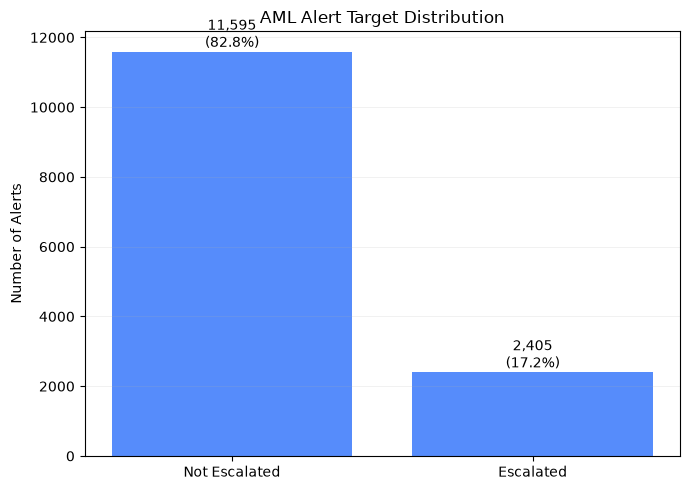

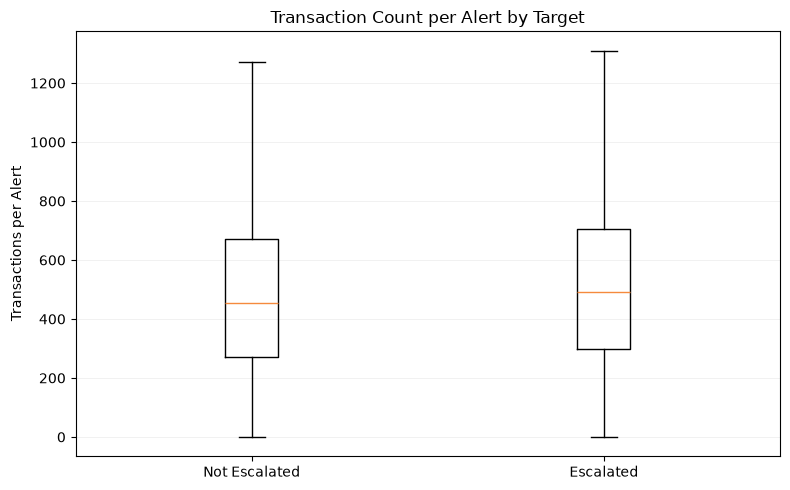

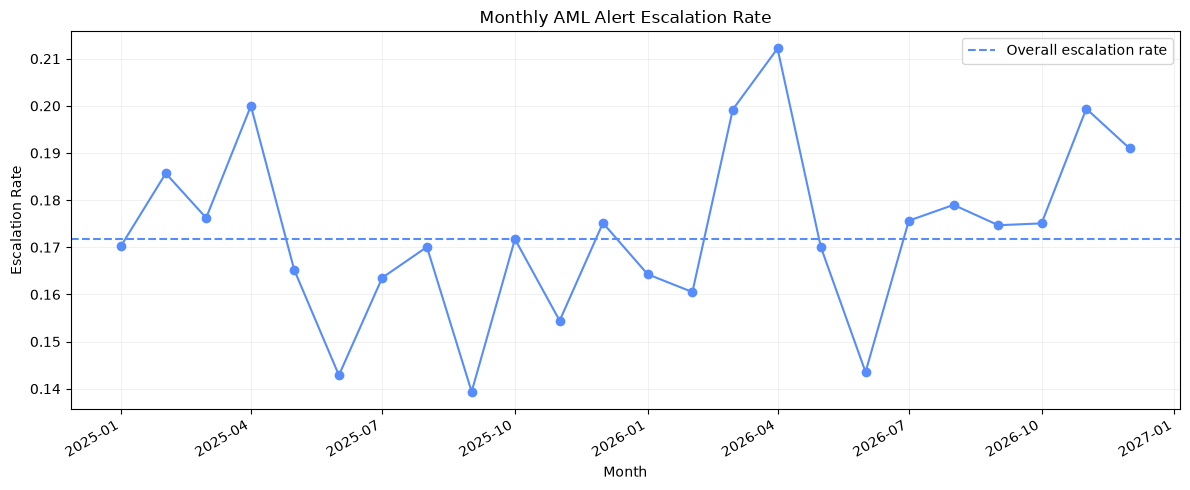

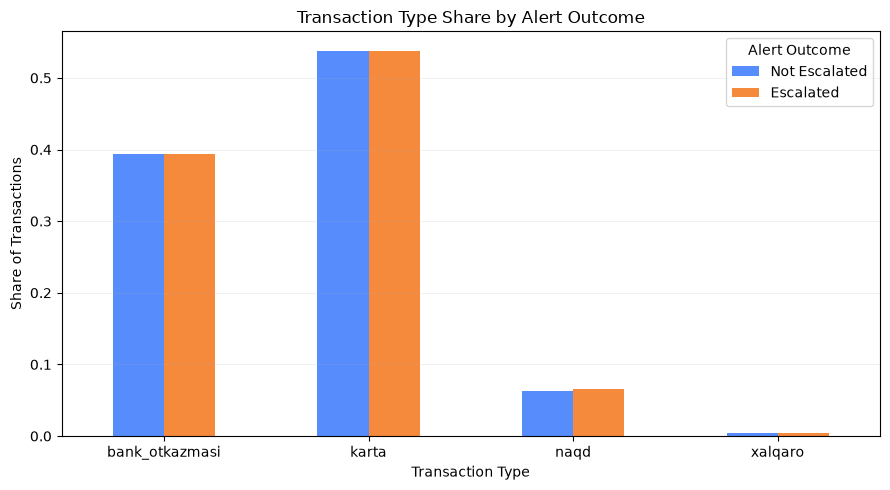

EDA CHARTS CREATED
01_target_distribution.png -> OK
02_transaction_count_by_target.png -> OK
03_monthly_escalation_rate.png -> OK
04_transaction_type_share.png -> OK

Saved to: C:\Users\khaki\PycharmProjects\aml-alert-prioritization\outputs\eda

All 4 EDA charts created successfully.


In [6]:
# ============================================================
# CELL 6 — EDA VISUALIZATIONS
# ============================================================

import matplotlib.pyplot as plt

EDA_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "eda"

EDA_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# CHART 1 — TARGET DISTRIBUTION
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 5)
)

labels = [
    "Not Escalated",
    "Escalated"
]

values = [
    target_counts.get(0, 0),
    target_counts.get(1, 0)
]

bars = ax.bar(
    labels,
    values
)

ax.set_title(
    "AML Alert Target Distribution"
)

ax.set_ylabel(
    "Number of Alerts"
)

ax.grid(
    axis="y",
    alpha=0.25
)


for bar, value in zip(
    bars,
    values
):

    rate = value / sum(values)

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}\n({rate:.1%})",
        ha="center",
        va="bottom"
    )


fig.tight_layout()

fig.savefig(
    EDA_OUTPUT_DIR / "01_target_distribution.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# CHART 2 — TRANSACTION COUNT BY TARGET
# ============================================================

plot_alerts = (
    eda_alert_level[
        [
            "eskalatsiya",
            "transaction_count"
        ]
    ]
    .copy()
)


visual_limit = (
    plot_alerts[
        "transaction_count"
    ]
    .quantile(0.99)
)


plot_alerts[
    "transaction_count_visual"
] = (
    plot_alerts[
        "transaction_count"
    ]
    .clip(
        upper=visual_limit
    )
)


group0 = (
    plot_alerts.loc[
        plot_alerts["eskalatsiya"] == 0,
        "transaction_count_visual"
    ]
)


group1 = (
    plot_alerts.loc[
        plot_alerts["eskalatsiya"] == 1,
        "transaction_count_visual"
    ]
)


fig, ax = plt.subplots(
    figsize=(8, 5)
)


# NOTE:
# Newer Matplotlib versions use tick_labels
# instead of labels.
ax.boxplot(
    [group0, group1],
    tick_labels=[
        "Not Escalated",
        "Escalated"
    ],
    showfliers=False
)


ax.set_title(
    "Transaction Count per Alert by Target"
)

ax.set_ylabel(
    "Transactions per Alert"
)

ax.grid(
    axis="y",
    alpha=0.25
)


fig.tight_layout()

fig.savefig(
    EDA_OUTPUT_DIR / "02_transaction_count_by_target.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# CHART 3 — MONTHLY ESCALATION RATE
# ============================================================

monthly_plot = (
    eda_monthly_target.copy()
)


monthly_plot[
    "month_dt"
] = pd.to_datetime(
    monthly_plot["month"]
)


fig, ax = plt.subplots(
    figsize=(12, 5)
)


ax.plot(
    monthly_plot["month_dt"],
    monthly_plot["escalation_rate"],
    marker="o"
)


ax.axhline(
    train_signals[
        "eskalatsiya"
    ].mean(),
    linestyle="--",
    linewidth=1.5,
    label="Overall escalation rate"
)


ax.set_title(
    "Monthly AML Alert Escalation Rate"
)

ax.set_xlabel(
    "Month"
)

ax.set_ylabel(
    "Escalation Rate"
)

ax.grid(
    alpha=0.25
)

ax.legend()

fig.autofmt_xdate()

fig.tight_layout()


fig.savefig(
    EDA_OUTPUT_DIR / "03_monthly_escalation_rate.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# CHART 4 — TRANSACTION TYPE SHARE BY TARGET
# ============================================================

type_plot = (
    eda_type_by_target
    .T
    .copy()
)


type_plot.columns = [
    "Not Escalated",
    "Escalated"
]


fig, ax = plt.subplots(
    figsize=(9, 5)
)


type_plot.plot(
    kind="bar",
    ax=ax
)


ax.set_title(
    "Transaction Type Share by Alert Outcome"
)

ax.set_xlabel(
    "Transaction Type"
)

ax.set_ylabel(
    "Share of Transactions"
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.legend(
    title="Alert Outcome"
)

plt.xticks(
    rotation=0
)


fig.tight_layout()


fig.savefig(
    EDA_OUTPUT_DIR / "04_transaction_type_share.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# CONFIRM SAVED FILES
# ============================================================

print("=" * 80)
print("EDA CHARTS CREATED")
print("=" * 80)


expected_charts = [
    "01_target_distribution.png",
    "02_transaction_count_by_target.png",
    "03_monthly_escalation_rate.png",
    "04_transaction_type_share.png"
]


for filename in expected_charts:

    path = (
        EDA_OUTPUT_DIR
        /
        filename
    )

    print(
        filename,
        "->",
        "OK" if path.exists() else "MISSING"
    )


print(
    "\nSaved to:",
    EDA_OUTPUT_DIR
)


assert all(
    (
        EDA_OUTPUT_DIR
        /
        filename
    ).exists()

    for filename in expected_charts
)


print("\nAll 4 EDA charts created successfully.")

In [7]:
# ============================================================
# CELL 7 — VERIFIED 53-FEATURE BUILDER
# ============================================================

FINAL_FEATURES = [

    # --------------------------------------------------------
    # Core transaction behaviour
    # --------------------------------------------------------

    "transaction_count",
    "amount_mean",
    "amount_std",
    "amount_min",
    "amount_max",
    "amount_median",

    "incoming_count",
    "outgoing_count",
    "incoming_ratio",
    "outgoing_ratio",

    "type_karta_count",
    "type_bank_otkazmasi_count",
    "type_naqd_count",
    "type_xalqaro_count",

    # --------------------------------------------------------
    # Recent transaction behaviour
    # --------------------------------------------------------

    "tx_last_1d",
    "tx_last_7d",
    "tx_last_30d",
    "tx_last_90d",

    "amount_mean_1d",
    "amount_mean_7d",
    "amount_mean_30d",
    "amount_std_30d",
    "amount_max_30d",

    # --------------------------------------------------------
    # Time-of-day / weekend behaviour
    # --------------------------------------------------------

    "night_tx_count",
    "weekend_tx_count",
    "tx_hour_mean",
    "tx_hour_std",
    "night_tx_ratio",
    "weekend_tx_ratio",

    "night_last_7d",
    "night_last_30d",
    "weekend_last_7d",
    "weekend_last_30d",

    # --------------------------------------------------------
    # Conditional minimum amount features
    # --------------------------------------------------------

    "amount_min_karta",
    "amount_min_bank_otkazmasi",
    "amount_min_naqd",
    "amount_min_outgoing",

    # --------------------------------------------------------
    # Conditional median amount features
    # --------------------------------------------------------

    "amount_median_karta",
    "amount_median_bank_otkazmasi",
    "amount_median_naqd",
    "amount_median_outgoing",

    # --------------------------------------------------------
    # Conditional mean amount features
    # --------------------------------------------------------

    "amount_mean_karta",
    "amount_mean_bank_otkazmasi",
    "amount_mean_naqd",
    "amount_mean_outgoing",

    # --------------------------------------------------------
    # Conditional maximum amount features
    # --------------------------------------------------------

    "amount_max_karta",
    "amount_max_bank_otkazmasi",
    "amount_max_naqd",
    "amount_max_outgoing",

    # --------------------------------------------------------
    # Conditional standard-deviation features
    # --------------------------------------------------------

    "amount_std_karta",
    "amount_std_bank_otkazmasi",
    "amount_std_naqd",
    "amount_std_outgoing",
]


assert len(FINAL_FEATURES) == 53
assert len(set(FINAL_FEATURES)) == 53


def build_final_53_features(
    signals,
    transactions
):
    """
    Build the exact 53 alert-level features used by the
    verified AML modelling pipeline.

    Parameters
    ----------
    signals : DataFrame
        Must contain:
            signal_id
            signal_sanasi

    transactions : DataFrame
        Leakage-safe transaction history containing:
            signal_id
            tranzaksiya_vaqti
            kirim_chiqim
            tranzaksiya_turi
            miqdor_indeksi

    Returns
    -------
    DataFrame
        signal_id + 53 model features
    """

    # --------------------------------------------------------
    # Prepare signal table
    # --------------------------------------------------------

    signal_base = (
        signals[
            [
                "signal_id",
                "signal_sanasi"
            ]
        ]
        .copy()
    )

    signal_base["signal_sanasi"] = pd.to_datetime(
        signal_base["signal_sanasi"]
    )


    # --------------------------------------------------------
    # Prepare transaction table
    # --------------------------------------------------------

    tx = transactions.copy()

    tx["tranzaksiya_vaqti"] = pd.to_datetime(
        tx["tranzaksiya_vaqti"]
    )


    tx = tx.merge(
        signal_base,
        on="signal_id",
        how="left",
        validate="many_to_one"
    )


    if tx["signal_sanasi"].isna().any():
        raise ValueError(
            "Transactions contain unknown signal IDs."
        )


    # Final safety check
    if (
        tx["tranzaksiya_vaqti"]
        >
        tx["signal_sanasi"]
    ).any():

        raise ValueError(
            "Post-alert transactions detected."
        )


    # --------------------------------------------------------
    # Time variables
    # --------------------------------------------------------

    tx["days_before_signal"] = (
        (
            tx["signal_sanasi"]
            -
            tx["tranzaksiya_vaqti"]
        )
        .dt.total_seconds()
        /
        86400.0
    )


    # IMPORTANT:
    # Verified original feature uses integer hour.
    tx["tx_hour"] = (
        tx["tranzaksiya_vaqti"]
        .dt.hour
        .astype(float)
    )


    tx["is_weekend"] = (
        tx["tranzaksiya_vaqti"]
        .dt.dayofweek
        .ge(5)
        .astype(np.int8)
    )


    # Verified night definition:
    # hour < 6 OR hour >= 23
    tx["is_night"] = (
        (
            tx["tranzaksiya_vaqti"]
            .dt.hour
            <
            6
        )
        |
        (
            tx["tranzaksiya_vaqti"]
            .dt.hour
            >=
            23
        )
    ).astype(np.int8)


    # --------------------------------------------------------
    # Basic amount / count features
    # --------------------------------------------------------

    grouped = tx.groupby(
        "signal_id",
        sort=False
    )


    base = grouped.agg(

        transaction_count=(
            "miqdor_indeksi",
            "size"
        ),

        amount_mean=(
            "miqdor_indeksi",
            "mean"
        ),

        amount_std=(
            "miqdor_indeksi",
            "std"
        ),

        amount_min=(
            "miqdor_indeksi",
            "min"
        ),

        amount_max=(
            "miqdor_indeksi",
            "max"
        ),

        amount_median=(
            "miqdor_indeksi",
            "median"
        ),

        tx_hour_mean=(
            "tx_hour",
            "mean"
        ),

        tx_hour_std=(
            "tx_hour",
            "std"
        ),

        night_tx_count=(
            "is_night",
            "sum"
        ),

        weekend_tx_count=(
            "is_weekend",
            "sum"
        )
    )


    # --------------------------------------------------------
    # Incoming / outgoing
    # --------------------------------------------------------

    direction_counts = pd.crosstab(
        tx["signal_id"],
        tx["kirim_chiqim"]
    )


    base["incoming_count"] = (
        direction_counts
        .get(
            "kirim",
            pd.Series(
                0,
                index=base.index
            )
        )
        .reindex(base.index)
        .fillna(0)
    )


    base["outgoing_count"] = (
        direction_counts
        .get(
            "chiqim",
            pd.Series(
                0,
                index=base.index
            )
        )
        .reindex(base.index)
        .fillna(0)
    )


    base["incoming_ratio"] = (
        base["incoming_count"]
        /
        base["transaction_count"]
    )


    base["outgoing_ratio"] = (
        base["outgoing_count"]
        /
        base["transaction_count"]
    )


    # --------------------------------------------------------
    # Transaction-type counts
    # --------------------------------------------------------

    type_counts = pd.crosstab(
        tx["signal_id"],
        tx["tranzaksiya_turi"]
    )


    for tx_type in [
        "karta",
        "bank_otkazmasi",
        "naqd",
        "xalqaro"
    ]:

        base[
            f"type_{tx_type}_count"
        ] = (
            type_counts
            .get(
                tx_type,
                pd.Series(
                    0,
                    index=base.index
                )
            )
            .reindex(base.index)
            .fillna(0)
        )


    # --------------------------------------------------------
    # Recent transaction windows
    # --------------------------------------------------------

    for days in [
        1,
        7,
        30,
        90
    ]:

        mask = (
            tx["days_before_signal"]
            <=
            days
        )

        counts = (
            tx.loc[mask]
            .groupby("signal_id")
            .size()
        )

        base[
            f"tx_last_{days}d"
        ] = (
            counts
            .reindex(base.index)
            .fillna(0)
        )


    # --------------------------------------------------------
    # Recent amount means
    # --------------------------------------------------------

    for days in [
        1,
        7,
        30
    ]:

        mask = (
            tx["days_before_signal"]
            <=
            days
        )

        recent_mean = (
            tx.loc[mask]
            .groupby("signal_id")[
                "miqdor_indeksi"
            ]
            .mean()
        )

        base[
            f"amount_mean_{days}d"
        ] = (
            recent_mean
            .reindex(base.index)
        )


    # --------------------------------------------------------
    # 30-day amount std / max
    # --------------------------------------------------------

    mask_30 = (
        tx["days_before_signal"]
        <=
        30
    )


    amount_std_30 = (
        tx.loc[mask_30]
        .groupby("signal_id")[
            "miqdor_indeksi"
        ]
        .std()
    )


    amount_max_30 = (
        tx.loc[mask_30]
        .groupby("signal_id")[
            "miqdor_indeksi"
        ]
        .max()
    )


    base["amount_std_30d"] = (
        amount_std_30
        .reindex(base.index)
    )


    base["amount_max_30d"] = (
        amount_max_30
        .reindex(base.index)
    )


    # --------------------------------------------------------
    # Night / weekend ratios
    # --------------------------------------------------------

    base["night_tx_ratio"] = (
        base["night_tx_count"]
        /
        base["transaction_count"]
    )


    base["weekend_tx_ratio"] = (
        base["weekend_tx_count"]
        /
        base["transaction_count"]
    )


    # --------------------------------------------------------
    # Recent night/weekend behaviour
    # --------------------------------------------------------

    for days in [
        7,
        30
    ]:

        recent = tx.loc[
            tx["days_before_signal"]
            <=
            days
        ]


        night_recent = (
            recent.groupby(
                "signal_id"
            )["is_night"]
            .sum()
        )


        weekend_recent = (
            recent.groupby(
                "signal_id"
            )["is_weekend"]
            .sum()
        )


        base[
            f"night_last_{days}d"
        ] = (
            night_recent
            .reindex(base.index)
            .fillna(0)
        )


        base[
            f"weekend_last_{days}d"
        ] = (
            weekend_recent
            .reindex(base.index)
            .fillna(0)
        )


    # --------------------------------------------------------
    # Conditional amount statistics
    # --------------------------------------------------------

    conditional_groups = {

        "karta": (
            tx["tranzaksiya_turi"]
            ==
            "karta"
        ),

        "bank_otkazmasi": (
            tx["tranzaksiya_turi"]
            ==
            "bank_otkazmasi"
        ),

        "naqd": (
            tx["tranzaksiya_turi"]
            ==
            "naqd"
        ),

        "outgoing": (
            tx["kirim_chiqim"]
            ==
            "chiqim"
        )
    }


    conditional_stats = [
        "min",
        "median",
        "mean",
        "max",
        "std"
    ]


    for group_name, mask in conditional_groups.items():

        group_tx = tx.loc[
            mask,
            [
                "signal_id",
                "miqdor_indeksi"
            ]
        ]


        stats = (
            group_tx.groupby(
                "signal_id"
            )["miqdor_indeksi"]
            .agg(
                conditional_stats
            )
        )


        for stat in conditional_stats:

            base[
                f"amount_{stat}_{group_name}"
            ] = (
                stats[stat]
                .reindex(base.index)
            )


    # --------------------------------------------------------
    # Verified zero-fill rules
    # --------------------------------------------------------

    zero_fill_columns = [

        "amount_std",
        "amount_std_30d",

        "amount_mean_1d",
        "amount_mean_7d",

        "tx_hour_std",

        "night_last_7d",
        "night_last_30d",

        "weekend_last_7d",
        "weekend_last_30d"
    ]


    for column in zero_fill_columns:

        base[column] = (
            base[column]
            .fillna(0)
        )


    # --------------------------------------------------------
    # Restore exact signal order
    # --------------------------------------------------------

    features = (
        signal_base[
            ["signal_id"]
        ]
        .merge(
            base.reset_index(),
            on="signal_id",
            how="left",
            validate="one_to_one"
        )
    )


    # --------------------------------------------------------
    # Final feature order
    # --------------------------------------------------------

    features = features[
        ["signal_id"]
        +
        FINAL_FEATURES
    ]


    return features


print("=" * 80)
print("VERIFIED FEATURE PIPELINE DEFINED")
print("=" * 80)

print(
    "Number of model features:",
    len(FINAL_FEATURES)
)

print(
    "Unique feature names:",
    len(set(FINAL_FEATURES))
)

print(
    "Feature builder ready:",
    callable(build_final_53_features)
)

print("\nFirst 10 features:")

for feature in FINAL_FEATURES[:10]:
    print(" -", feature)

print("\nCell 7 complete.")

VERIFIED FEATURE PIPELINE DEFINED
Number of model features: 53
Unique feature names: 53
Feature builder ready: True

First 10 features:
 - transaction_count
 - amount_mean
 - amount_std
 - amount_min
 - amount_max
 - amount_median
 - incoming_count
 - outgoing_count
 - incoming_ratio
 - outgoing_ratio

Cell 7 complete.


In [8]:
# ============================================================
# CELL 8 — BUILD + AUDIT TRAINING FEATURE MATRIX
# ============================================================

import time

print("=" * 80)
print("BUILDING VERIFIED 53-FEATURE TRAIN MATRIX")
print("=" * 80)

start_time = time.time()


# ------------------------------------------------------------
# Build features from leakage-safe history
# ------------------------------------------------------------

train_53 = build_final_53_features(
    train_signals,
    tx_history
)


elapsed = time.time() - start_time


print(
    f"\nFeature generation finished in "
    f"{elapsed / 60:.2f} minutes."
)


# ------------------------------------------------------------
# Basic shape / ID audit
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TRAIN FEATURE AUDIT")
print("=" * 80)

print(
    "Shape:",
    train_53.shape
)

print(
    "Expected shape:",
    (14000, 54)
)

print(
    "Unique IDs:",
    train_53["signal_id"].nunique()
)

print(
    "Expected IDs:",
    train_signals["signal_id"].nunique()
)


same_ids = (
    set(train_53["signal_id"])
    ==
    set(train_signals["signal_id"])
)

same_order = (
    train_53["signal_id"]
    .reset_index(drop=True)
    .equals(
        train_signals["signal_id"]
        .reset_index(drop=True)
    )
)


print(
    "IDs exactly match:",
    same_ids
)

print(
    "Same order as train_signals:",
    same_order
)


# ------------------------------------------------------------
# Feature-column audit
# ------------------------------------------------------------

actual_features = [
    c
    for c in train_53.columns
    if c != "signal_id"
]


print(
    "\nNumber of features:",
    len(actual_features)
)

print(
    "Feature order correct:",
    actual_features == FINAL_FEATURES
)


# ------------------------------------------------------------
# Numeric integrity audit
# ------------------------------------------------------------

X_train_raw = (
    train_53[
        FINAL_FEATURES
    ]
    .copy()
)


inf_count = int(
    np.isinf(
        X_train_raw
        .to_numpy(dtype=float)
    ).sum()
)


missing_count = int(
    X_train_raw
    .isna()
    .sum()
    .sum()
)


print(
    "\nInfinite values:",
    inf_count
)

print(
    "Missing values:",
    missing_count
)


# Missing values are allowed only in conditional
# amount statistics when a signal has no transaction
# from the relevant category.

missing_by_feature = (
    X_train_raw
    .isna()
    .sum()
)

missing_by_feature = (
    missing_by_feature[
        missing_by_feature > 0
    ]
    .sort_values(
        ascending=False
    )
)


print(
    "\nFeatures containing missing values:"
)

if len(missing_by_feature) == 0:

    print("None")

else:

    print(
        missing_by_feature.to_string()
    )


# ------------------------------------------------------------
# Critical transaction-count alignment check
# ------------------------------------------------------------

true_counts = (
    tx_history.groupby(
        "signal_id"
    )
    .size()
)


expected_counts = (
    train_53["signal_id"]
    .map(true_counts)
    .to_numpy()
)


actual_counts = (
    train_53[
        "transaction_count"
    ]
    .to_numpy()
)


count_matches = int(
    np.sum(
        expected_counts
        ==
        actual_counts
    )
)


count_corr = float(
    np.corrcoef(
        expected_counts,
        actual_counts
    )[0, 1]
)


print(
    "\nTransaction-count exact matches:",
    count_matches,
    "/",
    len(train_53)
)

print(
    "Transaction-count correlation:",
    count_corr
)


# ------------------------------------------------------------
# Hard assertions
# ------------------------------------------------------------

assert train_53.shape == (
    14000,
    54
)

assert train_53[
    "signal_id"
].is_unique

assert same_ids

assert same_order

assert actual_features == FINAL_FEATURES

assert inf_count == 0

assert count_matches == 14000

assert np.isclose(
    count_corr,
    1.0
)


# ------------------------------------------------------------
# Create explicitly aligned modelling table
# ------------------------------------------------------------

train_model_table = (
    train_signals[
        [
            "signal_id",
            "signal_sanasi",
            "eskalatsiya"
        ]
    ]
    .merge(
        train_53,
        on="signal_id",
        how="inner",
        validate="one_to_one"
    )
)


assert len(
    train_model_table
) == 14000


print("\n" + "=" * 80)
print("TRAIN FEATURE MATRIX VERIFIED")
print("=" * 80)

print(
    "train_53:",
    train_53.shape
)

print(
    "train_model_table:",
    train_model_table.shape
)

print(
    "Target positive rate:",
    train_model_table[
        "eskalatsiya"
    ].mean()
)

print(
    "\nSUCCESS: 53-feature training matrix is aligned by signal_id."
)

BUILDING VERIFIED 53-FEATURE TRAIN MATRIX

Feature generation finished in 0.20 minutes.

TRAIN FEATURE AUDIT
Shape: (14000, 54)
Expected shape: (14000, 54)
Unique IDs: 14000
Expected IDs: 14000
IDs exactly match: True
Same order as train_signals: True

Number of features: 53
Feature order correct: True

Infinite values: 0
Missing values: 3211

Features containing missing values:
amount_std_naqd                 516
amount_min_naqd                 294
amount_median_naqd              294
amount_max_naqd                 294
amount_mean_naqd                294
amount_std_outgoing             167
amount_std_karta                158
amount_std_bank_otkazmasi       146
amount_median_outgoing          106
amount_max_outgoing             106
amount_min_outgoing             106
amount_mean_outgoing            106
amount_max_karta                 84
amount_min_karta                 84
amount_median_karta              84
amount_mean_karta                84
amount_min_bank_otkazmasi        72
amount

In [9]:
# ============================================================
# CELL 9 — CHRONOLOGICAL MODELLING DATA + VALIDATION FOLDS
# ============================================================

print("=" * 80)
print("CREATING CHRONOLOGICAL MODELLING DATA")
print("=" * 80)


# ------------------------------------------------------------
# Sort explicitly by date, then signal_id
# ------------------------------------------------------------

train_master = (
    train_model_table
    .sort_values(
        [
            "signal_sanasi",
            "signal_id"
        ]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Canonical X / y
# ------------------------------------------------------------

X = (
    train_master[
        FINAL_FEATURES
    ]
    .copy()
)


y = (
    train_master[
        "eskalatsiya"
    ]
    .astype(int)
    .copy()
)


print(
    "X shape:",
    X.shape
)

print(
    "y shape:",
    y.shape
)

print(
    "Positive rate:",
    y.mean()
)

print(
    "First signal date:",
    train_master[
        "signal_sanasi"
    ].min().date()
)

print(
    "Last signal date:",
    train_master[
        "signal_sanasi"
    ].max().date()
)


# ------------------------------------------------------------
# Chronological validation periods
# ------------------------------------------------------------

VALIDATION_PERIODS = [

    (
        "2026-04-01",
        "2026-05-31"
    ),

    (
        "2026-06-01",
        "2026-08-07"
    ),

    (
        "2026-08-08",
        "2026-09-30"
    ),

    (
        "2026-10-01",
        "2026-12-31"
    )
]


folds = []


print("\n" + "=" * 80)
print("CHRONOLOGICAL VALIDATION FOLDS")
print("=" * 80)


for fold_number, (
    valid_start,
    valid_end
) in enumerate(
    VALIDATION_PERIODS,
    start=1
):

    valid_start = pd.Timestamp(
        valid_start
    )

    valid_end = pd.Timestamp(
        valid_end
    )


    train_idx = train_master.index[
        train_master[
            "signal_sanasi"
        ]
        <
        valid_start
    ].to_numpy()


    valid_idx = train_master.index[
        (
            train_master[
                "signal_sanasi"
            ]
            >=
            valid_start
        )
        &
        (
            train_master[
                "signal_sanasi"
            ]
            <=
            valid_end
        )
    ].to_numpy()


    assert len(train_idx) > 0
    assert len(valid_idx) > 0


    train_dates = (
        train_master.loc[
            train_idx,
            "signal_sanasi"
        ]
    )


    valid_dates = (
        train_master.loc[
            valid_idx,
            "signal_sanasi"
        ]
    )


    # Strict temporal separation
    assert (
        train_dates.max()
        <
        valid_dates.min()
    )


    same_boundary_date = (
        train_dates.max()
        ==
        valid_dates.min()
    )


    folds.append(
        (
            train_idx,
            valid_idx
        )
    )


    print(
        f"\nFold {fold_number}"
    )

    print(
        "Train rows:",
        len(train_idx)
    )

    print(
        "Valid rows:",
        len(valid_idx)
    )

    print(
        "Train dates:",
        train_dates.min().date(),
        "to",
        train_dates.max().date()
    )

    print(
        "Valid dates:",
        valid_dates.min().date(),
        "to",
        valid_dates.max().date()
    )

    print(
        "Train positive rate:",
        y.iloc[
            train_idx
        ].mean()
    )

    print(
        "Valid positive rate:",
        y.iloc[
            valid_idx
        ].mean()
    )

    print(
        "Same boundary date:",
        same_boundary_date
    )


# ------------------------------------------------------------
# Final integrity checks
# ------------------------------------------------------------

assert X.shape == (
    14000,
    53
)

assert len(y) == 14000

assert len(folds) == 4

assert np.isclose(
    y.mean(),
    0.1717857142857143
)


print("\n" + "=" * 80)
print("CHRONOLOGICAL DATASET VERIFIED")
print("=" * 80)

print(
    "Rows:",
    len(train_master)
)

print(
    "Features:",
    X.shape[1]
)

print(
    "Folds:",
    len(folds)
)

print(
    "\nSUCCESS: X, y and validation folds are aligned chronologically."
)

CREATING CHRONOLOGICAL MODELLING DATA
X shape: (14000, 53)
y shape: (14000,)
Positive rate: 0.1717857142857143
First signal date: 2025-01-01
Last signal date: 2026-12-31

CHRONOLOGICAL VALIDATION FOLDS

Fold 1
Train rows: 9837
Valid rows: 1243
Train dates: 2025-01-01 to 2026-03-31
Valid dates: 2026-04-01 to 2026-05-31
Train positive rate: 0.1688522923655586
Valid positive rate: 0.1906677393403057
Same boundary date: False

Fold 2
Train rows: 11080
Valid rows: 1159
Train dates: 2025-01-01 to 2026-05-31
Valid dates: 2026-06-01 to 2026-08-07
Train positive rate: 0.17129963898916967
Valid positive rate: 0.15962036238136323
Same boundary date: False

Fold 3
Train rows: 12239
Valid rows: 716
Train dates: 2025-01-01 to 2026-08-07
Valid dates: 2026-08-08 to 2026-09-30
Train positive rate: 0.1701936432715091
Valid positive rate: 0.17458100558659218
Same boundary date: False

Fold 4
Train rows: 12955
Valid rows: 1045
Train dates: 2025-01-01 to 2026-09-30
Valid dates: 2026-10-01 to 2026-12-31
Tra

In [10]:
# ============================================================
# CELL 10 — BUILD + AUDIT TEST FEATURE MATRIX
# ============================================================

import time

print("=" * 80)
print("BUILDING VERIFIED 53-FEATURE TEST MATRIX")
print("=" * 80)

start_time = time.time()


# ------------------------------------------------------------
# Build test features using EXACTLY the same function
# ------------------------------------------------------------

test_53 = build_final_53_features(
    test_signals,
    test_tx_history
)


elapsed = time.time() - start_time

print(
    f"\nFeature generation finished in "
    f"{elapsed / 60:.2f} minutes."
)


# ------------------------------------------------------------
# Shape / ID audit
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TEST FEATURE AUDIT")
print("=" * 80)

print(
    "Shape:",
    test_53.shape
)

print(
    "Expected shape:",
    (6000, 54)
)

print(
    "Unique IDs:",
    test_53["signal_id"].nunique()
)

print(
    "Expected IDs:",
    test_signals["signal_id"].nunique()
)


same_test_ids = (
    set(test_53["signal_id"])
    ==
    set(test_signals["signal_id"])
)


same_test_order = (
    test_53["signal_id"]
    .reset_index(drop=True)
    .equals(
        test_signals["signal_id"]
        .reset_index(drop=True)
    )
)


print(
    "IDs exactly match:",
    same_test_ids
)

print(
    "Same order as test_signals:",
    same_test_order
)


# ------------------------------------------------------------
# Feature audit
# ------------------------------------------------------------

test_feature_names = [
    c
    for c in test_53.columns
    if c != "signal_id"
]


print(
    "\nNumber of features:",
    len(test_feature_names)
)

print(
    "Feature order correct:",
    test_feature_names == FINAL_FEATURES
)


X_test = (
    test_53[
        FINAL_FEATURES
    ]
    .copy()
)


# ------------------------------------------------------------
# Numeric integrity
# ------------------------------------------------------------

test_inf_count = int(
    np.isinf(
        X_test.to_numpy(
            dtype=float
        )
    ).sum()
)


test_missing_count = int(
    X_test
    .isna()
    .sum()
    .sum()
)


print(
    "\nInfinite values:",
    test_inf_count
)

print(
    "Missing values:",
    test_missing_count
)


test_missing_by_feature = (
    X_test
    .isna()
    .sum()
)

test_missing_by_feature = (
    test_missing_by_feature[
        test_missing_by_feature > 0
    ]
    .sort_values(
        ascending=False
    )
)


print(
    "\nFeatures containing missing values:"
)

if len(test_missing_by_feature) == 0:

    print("None")

else:

    print(
        test_missing_by_feature.to_string()
    )


# ------------------------------------------------------------
# Critical transaction-count alignment check
# ------------------------------------------------------------

true_test_counts = (
    test_tx_history
    .groupby("signal_id")
    .size()
)


expected_test_counts = (
    test_53["signal_id"]
    .map(true_test_counts)
    .to_numpy()
)


actual_test_counts = (
    test_53[
        "transaction_count"
    ]
    .to_numpy()
)


test_count_matches = int(
    np.sum(
        expected_test_counts
        ==
        actual_test_counts
    )
)


test_count_corr = float(
    np.corrcoef(
        expected_test_counts,
        actual_test_counts
    )[0, 1]
)


print(
    "\nTransaction-count exact matches:",
    test_count_matches,
    "/",
    len(test_53)
)

print(
    "Transaction-count correlation:",
    test_count_corr
)


# ------------------------------------------------------------
# Hard assertions
# ------------------------------------------------------------

assert test_53.shape == (
    6000,
    54
)

assert test_53[
    "signal_id"
].is_unique

assert same_test_ids

assert same_test_order

assert test_feature_names == FINAL_FEATURES

assert test_inf_count == 0

assert test_count_matches == 6000

assert np.isclose(
    test_count_corr,
    1.0
)


# ------------------------------------------------------------
# Final test modelling table
# ------------------------------------------------------------

test_master = (
    test_signals[
        [
            "signal_id",
            "signal_sanasi"
        ]
    ]
    .merge(
        test_53,
        on="signal_id",
        how="inner",
        validate="one_to_one"
    )
)


assert len(
    test_master
) == 6000


# ------------------------------------------------------------
# Train/Test feature-distribution sanity check
# ------------------------------------------------------------

distribution_audit = pd.DataFrame({

    "train_mean":
        X.mean(),

    "test_mean":
        X_test.mean(),

    "train_std":
        X.std(),

    "test_std":
        X_test.std()

})


distribution_audit[
    "mean_difference"
] = (
    distribution_audit[
        "test_mean"
    ]
    -
    distribution_audit[
        "train_mean"
    ]
)


print("\n" + "=" * 80)
print("TEST FEATURE MATRIX VERIFIED")
print("=" * 80)

print(
    "test_53:",
    test_53.shape
)

print(
    "test_master:",
    test_master.shape
)

print(
    "X_test:",
    X_test.shape
)


print(
    "\nLargest absolute train/test mean differences:"
)

print(
    distribution_audit[
        "mean_difference"
    ]
    .abs()
    .sort_values(
        ascending=False
    )
    .head(10)
    .to_string()
)


print("\nSUCCESS: 53-feature test matrix is aligned by signal_id.")

BUILDING VERIFIED 53-FEATURE TEST MATRIX

Feature generation finished in 0.05 minutes.

TEST FEATURE AUDIT
Shape: (6000, 54)
Expected shape: (6000, 54)
Unique IDs: 6000
Expected IDs: 6000
IDs exactly match: True
Same order as test_signals: True

Number of features: 53
Feature order correct: True

Infinite values: 0
Missing values: 1279

Features containing missing values:
amount_std_naqd                 188
amount_min_naqd                 104
amount_median_naqd              104
amount_max_naqd                 104
amount_mean_naqd                104
amount_std_karta                 73
amount_std_outgoing              66
amount_std_bank_otkazmasi        60
amount_median_outgoing           48
amount_max_outgoing              48
amount_min_outgoing              48
amount_mean_outgoing             48
amount_max_karta                 40
amount_min_karta                 40
amount_median_karta              40
amount_mean_karta                40
amount_min_bank_otkazmasi        31
amount_median

In [11]:
# ============================================================
# STEP 109 — CLEAN NOTEBOOK: REPRODUCIBLE 31-FEATURE CV
#
# Candidate:
#   frozen STABLE_26
#   + five 90-day amount statistics
#
# This cell:
#   1. builds the 90-day features from safe history,
#   2. aligns them explicitly by signal_id,
#   3. runs the actual four chronological folds,
#   4. derives final per-seed iteration counts.
#
# It does NOT write or overwrite any CSV.
# ============================================================

import numpy as np
import pandas as pd

from lightgbm import (
    LGBMClassifier,
    early_stopping,
    log_evaluation,
)

from sklearn.metrics import roc_auc_score


print("=" * 72)
print("STEP 109 — REPRODUCIBLE 31-FEATURE CHRONOLOGICAL CV")
print("=" * 72)


# ------------------------------------------------------------
# 1. Frozen configuration
# ------------------------------------------------------------

SEEDS_31 = [
    17,
    42,
    73,
    101,
    2026,
]


# ------------------------------------------------------------
# Frozen 26-feature core
# ------------------------------------------------------------

FINAL_26_FEATURES = [
    "amount_std_bank_otkazmasi",
    "amount_min_karta",
    "amount_min",
    "amount_max_karta",
    "amount_min_bank_otkazmasi",
    "amount_std_karta",
    "amount_mean_bank_otkazmasi",
    "amount_mean_naqd",
    "amount_max_outgoing",
    "amount_median_bank_otkazmasi",
    "amount_min_outgoing",
    "amount_median_naqd",
    "amount_max_naqd",
    "amount_median_karta",
    "tx_hour_mean",
    "weekend_last_30d",
    "amount_min_naqd",
    "amount_max_30d",
    "amount_max",
    "weekend_tx_count",
    "tx_last_90d",
    "amount_std_outgoing",
    "outgoing_count",
    "amount_median",
    "weekend_tx_ratio",
    "transaction_count",
]

assert len(FINAL_26_FEATURES) == 26
assert len(set(FINAL_26_FEATURES)) == 26

AMOUNT_90D_FEATURES = [
    "recent90d_amount_mean",
    "recent90d_amount_std",
    "recent90d_amount_min",
    "recent90d_amount_max",
    "recent90d_amount_median",
]

FINAL_31_FEATURES = (
    list(FINAL_26_FEATURES)
    + AMOUNT_90D_FEATURES
)

assert len(FINAL_26_FEATURES) == 26
assert len(FINAL_31_FEATURES) == 31
assert len(set(FINAL_31_FEATURES)) == 31


# ------------------------------------------------------------
# 2. Independent 90-day feature builder
# ------------------------------------------------------------

def build_90d_amount_features(
    signals,
    transactions,
):

    signal_dates = signals[
        [
            "signal_id",
            "signal_sanasi",
        ]
    ].copy()

    signal_dates[
        "signal_sanasi"
    ] = pd.to_datetime(
        signal_dates[
            "signal_sanasi"
        ]
    )

    work = transactions[
        [
            "signal_id",
            "tranzaksiya_vaqti",
            "miqdor_indeksi",
        ]
    ].copy()

    work[
        "tranzaksiya_vaqti"
    ] = pd.to_datetime(
        work[
            "tranzaksiya_vaqti"
        ]
    )

    work = work.merge(
        signal_dates,
        on="signal_id",
        how="inner",
        validate="many_to_one",
    )

    work[
        "age_seconds"
    ] = (
        work[
            "signal_sanasi"
        ]
        - work[
            "tranzaksiya_vaqti"
        ]
    ).dt.total_seconds()

    # Safe-history invariant.
    assert (
        work[
            "age_seconds"
        ] >= 0
    ).all()

    # Exact trailing 90-day window.
    work = work[
        work[
            "age_seconds"
        ] <= 90 * 86400
    ].copy()

    agg = (
        work
        .groupby(
            "signal_id"
        )[
            "miqdor_indeksi"
        ]
        .agg(
            recent90d_amount_mean="mean",
            recent90d_amount_std="std",
            recent90d_amount_min="min",
            recent90d_amount_max="max",
            recent90d_amount_median="median",
        )
        .reset_index()
    )

    result = (
        signal_dates[
            ["signal_id"]
        ]
        .merge(
            agg,
            on="signal_id",
            how="left",
            validate="one_to_one",
        )
    )

    assert len(result) == len(
        signal_dates
    )

    assert result[
        "signal_id"
    ].is_unique

    return result


# ------------------------------------------------------------
# 3. Build TRAIN + TEST 90-day features from safe history
# ------------------------------------------------------------

train_90d = build_90d_amount_features(
    train_signals,
    tx_history,
)

test_90d = build_90d_amount_features(
    test_signals,
    test_tx_history,
)

assert train_90d.shape == (
    14000,
    6,
)

assert test_90d.shape == (
    6000,
    6,
)

print(
    "Train 90d table:",
    train_90d.shape
)

print(
    "Test 90d table :",
    test_90d.shape
)


# ------------------------------------------------------------
# 4. Align TRAIN features to chronological train_master
#
# IMPORTANT:
# X/y/folds are chronological.
# Therefore the new features must be merged using the exact
# train_master signal_id order.
# ------------------------------------------------------------

train_31_table = (
    train_master[
        ["signal_id"]
        + list(
            FINAL_26_FEATURES
        )
    ]
    .merge(
        train_90d,
        on="signal_id",
        how="left",
        validate="one_to_one",
    )
)

assert len(
    train_31_table
) == len(
    train_master
)

assert (
    train_31_table[
        "signal_id"
    ].tolist()
    ==
    train_master[
        "signal_id"
    ].tolist()
)

X_31 = (
    train_31_table[
        FINAL_31_FEATURES
    ]
    .copy()
)

assert X_31.shape == (
    14000,
    31,
)

assert list(
    X_31.columns
) == FINAL_31_FEATURES


# ------------------------------------------------------------
# 5. Align TEST features to exact test_master order
# ------------------------------------------------------------

test_31_table = (
    test_master[
        ["signal_id"]
        + list(
            FINAL_26_FEATURES
        )
    ]
    .merge(
        test_90d,
        on="signal_id",
        how="left",
        validate="one_to_one",
    )
)

assert len(
    test_31_table
) == len(
    test_master
)

assert (
    test_31_table[
        "signal_id"
    ].tolist()
    ==
    test_master[
        "signal_id"
    ].tolist()
)

X_test_31 = (
    test_31_table[
        FINAL_31_FEATURES
    ]
    .copy()
)

assert X_test_31.shape == (
    6000,
    31,
)

assert list(
    X_test_31.columns
) == FINAL_31_FEATURES


# ------------------------------------------------------------
# 6. Integrity
# ------------------------------------------------------------

assert not np.isinf(
    X_31.to_numpy(
        dtype=float
    )
).any()

assert not np.isinf(
    X_test_31.to_numpy(
        dtype=float
    )
).any()

print(
    "\nTrain matrix:",
    X_31.shape
)

print(
    "Test matrix :",
    X_test_31.shape
)

print(
    "Train missing cells:",
    int(
        X_31
        .isna()
        .sum()
        .sum()
    )
)

print(
    "Test missing cells :",
    int(
        X_test_31
        .isna()
        .sum()
        .sum()
    )
)


# ------------------------------------------------------------
# 7. Locked LightGBM structure
# ------------------------------------------------------------

params_31 = dict(
    objective="binary",
    n_estimators=3000,
    learning_rate=0.01,
    num_leaves=15,
    max_depth=-1,
    min_child_samples=120,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=10.0,
    n_jobs=-1,
    verbosity=-1,
)


# ------------------------------------------------------------
# 8. REAL chronological validation
# ------------------------------------------------------------

iteration_records_31 = {
    seed: []
    for seed in SEEDS_31
}

fold_scores_31 = []

for fold_number, (
    tr_idx,
    va_idx
) in enumerate(
    folds,
    start=1,
):

    seed_predictions = []

    print(
        "\nFold",
        fold_number
    )

    for seed in SEEDS_31:

        model = LGBMClassifier(
            **params_31,
            random_state=seed,
        )

        model.fit(
            X_31.iloc[
                tr_idx
            ],
            y.iloc[
                tr_idx
            ],

            eval_set=[
                (
                    X_31.iloc[
                        va_idx
                    ],
                    y.iloc[
                        va_idx
                    ],
                )
            ],

            eval_metric="auc",

            callbacks=[
                early_stopping(
                    150,
                    verbose=False,
                ),
                log_evaluation(0),
            ],
        )

        prediction = (
            model.predict_proba(
                X_31.iloc[
                    va_idx
                ]
            )[:, 1]
        )

        seed_predictions.append(
            prediction
        )

        iteration_records_31[
            seed
        ].append(
            int(
                model.best_iteration_
            )
        )

        print(
            f"  Seed {seed:4d}: "
            f"iteration="
            f"{model.best_iteration_}"
        )

    ensemble_prediction = np.mean(
        np.vstack(
            seed_predictions
        ),
        axis=0,
    )

    fold_auc = roc_auc_score(
        y.iloc[
            va_idx
        ],
        ensemble_prediction,
    )

    fold_scores_31.append(
        float(
            fold_auc
        )
    )

    print(
        f"  Ensemble AUC: "
        f"{fold_auc:.6f}"
    )


# ------------------------------------------------------------
# 9. Derive final iteration counts
# ------------------------------------------------------------

FINAL_31_ITERATIONS = {}

iteration_rows_31 = []

for seed in SEEDS_31:

    values = (
        iteration_records_31[
            seed
        ]
    )

    median_iteration = int(
        np.median(
            values
        )
    )

    FINAL_31_ITERATIONS[
        seed
    ] = median_iteration

    iteration_rows_31.append({
        "seed": seed,
        "fold1": values[0],
        "fold2": values[1],
        "fold3": values[2],
        "fold4": values[3],
        "median":
            median_iteration,
    })

iteration_audit_31 = pd.DataFrame(
    iteration_rows_31
)


# ------------------------------------------------------------
# 10. Exact reproduction checks
# ------------------------------------------------------------

EXPECTED_FOLD_SCORES_31 = np.array([
    0.654646,
    0.661618,
    0.673462,
    0.679982,
])

EXPECTED_ITERATIONS_31 = {
    17: 392,
    42: 358,
    73: 453,
    101: 376,
    2026: 335,
}

fold_match_31 = np.allclose(
    np.array(
        fold_scores_31
    ),
    EXPECTED_FOLD_SCORES_31,
    atol=1e-6,
    rtol=0,
)

iteration_match_31 = (
    FINAL_31_ITERATIONS
    ==
    EXPECTED_ITERATIONS_31
)


# ------------------------------------------------------------
# 11. Final output
# ------------------------------------------------------------

print("\n" + "=" * 72)
print("STEP 109 — FINAL RESULT")
print("=" * 72)

print(
    "Fold AUCs:",
    ", ".join(
        f"{score:.6f}"
        for score in fold_scores_31
    )
)

print(
    f"Mean AUC : "
    f"{np.mean(fold_scores_31):.6f}"
)

print(
    f"Std AUC  : "
    f"{np.std(fold_scores_31):.6f}"
)

print(
    f"Worst AUC: "
    f"{np.min(fold_scores_31):.6f}"
)

print(
    "\nIteration audit:"
)

print(
    iteration_audit_31.to_string(
        index=False
    )
)

print(
    "\nFINAL_31_ITERATIONS =",
    FINAL_31_ITERATIONS
)

print(
    "\nFold-score reproduction:",
    "PASS"
    if fold_match_31
    else "FAIL"
)

print(
    "Iteration reproduction :",
    "PASS"
    if iteration_match_31
    else "FAIL"
)

if (
    fold_match_31
    and iteration_match_31
):
    print(
        "\nRESULT: CLEAN NOTEBOOK "
        "31-FEATURE CV REPRODUCED"
    )
else:
    print(
        "\nRESULT: REPRODUCTION FAILED — "
        "DO NOT PROMOTE"
    )

print("=" * 72)

STEP 109 — REPRODUCIBLE 31-FEATURE CHRONOLOGICAL CV
Train 90d table: (14000, 6)
Test 90d table : (6000, 6)

Train matrix: (14000, 31)
Test matrix : (6000, 31)
Train missing cells: 2469
Test missing cells : 984

Fold 1
  Seed   17: iteration=558
  Seed   42: iteration=470
  Seed   73: iteration=599
  Seed  101: iteration=507
  Seed 2026: iteration=623
  Ensemble AUC: 0.654646

Fold 2
  Seed   17: iteration=565
  Seed   42: iteration=522
  Seed   73: iteration=619
  Seed  101: iteration=576
  Seed 2026: iteration=490
  Ensemble AUC: 0.661618

Fold 3
  Seed   17: iteration=56
  Seed   42: iteration=92
  Seed   73: iteration=11
  Seed  101: iteration=5
  Seed 2026: iteration=12
  Ensemble AUC: 0.673462

Fold 4
  Seed   17: iteration=227
  Seed   42: iteration=246
  Seed   73: iteration=308
  Seed  101: iteration=246
  Seed 2026: iteration=180
  Ensemble AUC: 0.679982

STEP 109 — FINAL RESULT
Fold AUCs: 0.654646, 0.661618, 0.673462, 0.679982
Mean AUC : 0.667427
Std AUC  : 0.009889
Worst AUC

In [12]:
# ============================================================
# STEP 110 — CLEAN NOTEBOOK FULL-DATA 31-FEATURE REPRODUCTION
#
# Train the verified 31-feature model on all training alerts.
# Generate a SEPARATE reproduction CSV.
#
# REQUIRED RESULT:
# SHA256 must exactly equal the frozen experimental candidate:
#
# 1EC03DAECD4C6349924C445345FFFDCDB0CA258DF54FA052AD08C549D3C4C744
#
# Official team_5B7B633C.csv is NOT modified.
# ============================================================

import hashlib
import numpy as np
import pandas as pd
from pathlib import Path
from lightgbm import LGBMClassifier


print("=" * 72)
print("STEP 110 — FULL-DATA 31-FEATURE REPRODUCTION")
print("=" * 72)


# ------------------------------------------------------------
# 1. Frozen configuration from Step 109
# ------------------------------------------------------------

EXPECTED_ITERATIONS_110 = {
    17: 392,
    42: 358,
    73: 453,
    101: 376,
    2026: 335,
}

EXPECTED_CANDIDATE_HASH_110 = (
    "1EC03DAECD4C6349924C445345FFFDCDB0CA258DF54FA052AD08C549D3C4C744"
)

assert FINAL_31_ITERATIONS == EXPECTED_ITERATIONS_110

assert X_31.shape == (14000, 31)
assert X_test_31.shape == (6000, 31)

assert list(X_31.columns) == FINAL_31_FEATURES
assert list(X_test_31.columns) == FINAL_31_FEATURES


# ------------------------------------------------------------
# 2. Locked LightGBM configuration
# ------------------------------------------------------------

params_110 = dict(
    objective="binary",
    learning_rate=0.01,
    num_leaves=15,
    max_depth=-1,
    min_child_samples=120,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=10.0,
    n_jobs=-1,
    verbosity=-1,
)


# ------------------------------------------------------------
# 3. Full-data training
# ------------------------------------------------------------

seed_predictions_110 = []

print("\nTraining five full-data models...")

for seed in SEEDS_31:

    n_trees = FINAL_31_ITERATIONS[
        seed
    ]

    model = LGBMClassifier(
        **params_110,
        n_estimators=n_trees,
        random_state=seed,
    )

    model.fit(
        X_31,
        y,
    )

    prediction = model.predict_proba(
        X_test_31
    )[:, 1]

    assert len(prediction) == 6000
    assert np.isfinite(prediction).all()

    seed_predictions_110.append(
        prediction
    )

    print(
        f"Seed {seed:4d} | "
        f"trees={n_trees:3d} | "
        f"mean={prediction.mean():.8f} | "
        f"std={prediction.std():.8f}"
    )


final_prediction_31 = np.mean(
    np.vstack(
        seed_predictions_110
    ),
    axis=0,
)


# ------------------------------------------------------------
# 4. Prediction integrity
# ------------------------------------------------------------

assert len(final_prediction_31) == 6000
assert np.isfinite(final_prediction_31).all()

assert (
    final_prediction_31 >= 0
).all()

assert (
    final_prediction_31 <= 1
).all()


print("\n" + "=" * 72)
print("31-FEATURE CLEAN PREDICTION AUDIT")
print("=" * 72)

print(
    f"Count : {len(final_prediction_31)}"
)

print(
    f"Min   : {final_prediction_31.min():.8f}"
)

print(
    f"Max   : {final_prediction_31.max():.8f}"
)

print(
    f"Mean  : {final_prediction_31.mean():.8f}"
)

print(
    f"Median: {np.median(final_prediction_31):.8f}"
)

print(
    f"Std   : {final_prediction_31.std():.8f}"
)


# ------------------------------------------------------------
# 5. Build exact submission table
#
# IMPORTANT:
# test_master is already in verified test order.
# ------------------------------------------------------------

submission_31_repro = pd.DataFrame({
    "signal_id":
        test_master[
            "signal_id"
        ].values,

    "ehtimollik":
        final_prediction_31,
})

assert submission_31_repro.shape == (
    6000,
    2,
)

assert list(
    submission_31_repro.columns
) == [
    "signal_id",
    "ehtimollik",
]

assert submission_31_repro[
    "signal_id"
].is_unique

assert not submission_31_repro[
    "ehtimollik"
].isna().any()

assert submission_31_repro[
    "ehtimollik"
].between(
    0,
    1,
    inclusive="both",
).all()

assert (
    set(
        submission_31_repro[
            "signal_id"
        ]
    )
    ==
    set(
        test_signals[
            "signal_id"
        ]
    )
)


# ------------------------------------------------------------
# 6. Paths
# ------------------------------------------------------------

project_root_110 = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)

repro_path_110 = (
    project_root_110
    / "team_5B7B633C.csv"
)

candidate_path_110 = (
    project_root_110
    / "team_5B7B633C.csv"
)

official_path_110 = (
    project_root_110
    / "team_5B7B633C.csv"
)


# ------------------------------------------------------------
# 7. Write reproduction file ONLY
# ------------------------------------------------------------

submission_31_repro.to_csv(
    repro_path_110,
    index=False,
)

assert repro_path_110.exists()
assert candidate_path_110.exists()
assert official_path_110.exists()


# ------------------------------------------------------------
# 8. SHA256 helper
# ------------------------------------------------------------

def sha256_file_110(path):

    h = hashlib.sha256()

    with open(
        path,
        "rb",
    ) as f:

        for chunk in iter(
            lambda: f.read(
                1024 * 1024
            ),
            b"",
        ):
            h.update(chunk)

    return h.hexdigest().upper()


repro_hash_110 = sha256_file_110(
    repro_path_110
)

candidate_hash_110 = sha256_file_110(
    candidate_path_110
)

official_hash_110 = sha256_file_110(
    official_path_110
)


# ------------------------------------------------------------
# 9. Numerical comparison against experimental candidate
# ------------------------------------------------------------

candidate_disk_110 = pd.read_csv(
    candidate_path_110
)

candidate_aligned_110 = (
    submission_31_repro[
        ["signal_id"]
    ]
    .merge(
        candidate_disk_110,
        on="signal_id",
        how="left",
        validate="one_to_one",
    )
)

candidate_pred_110 = (
    candidate_aligned_110[
        "ehtimollik"
    ].to_numpy()
)

max_prediction_diff_110 = float(
    np.max(
        np.abs(
            final_prediction_31
            - candidate_pred_110
        )
    )
)


# ------------------------------------------------------------
# 10. Exact reproduction result
# ------------------------------------------------------------

hash_match_110 = (
    repro_hash_110
    ==
    EXPECTED_CANDIDATE_HASH_110
)

candidate_hash_match_110 = (
    candidate_hash_110
    ==
    EXPECTED_CANDIDATE_HASH_110
)

prediction_match_110 = (
    max_prediction_diff_110
    < 1e-12
)


print("\n" + "=" * 72)
print("STEP 110 — REPRODUCTION RESULT")
print("=" * 72)

print(
    "Reproduction CSV:"
)

print(
    repro_path_110.resolve()
)

print(
    "\nReproduction SHA256:"
)

print(
    repro_hash_110
)

print(
    "\nFrozen candidate SHA256:"
)

print(
    candidate_hash_110
)

print(
    "\nExpected candidate SHA256:"
)

print(
    EXPECTED_CANDIDATE_HASH_110
)

print(
    "\nCurrent official SHA256:"
)

print(
    official_hash_110
)

print(
    "\nMax prediction difference:"
)

print(
    f"{max_prediction_diff_110:.16g}"
)

print(
    "\nReproduction hash match:",
    "PASS"
    if hash_match_110
    else "FAIL"
)

print(
    "Frozen candidate hash match:",
    "PASS"
    if candidate_hash_match_110
    else "FAIL"
)

print(
    "Prediction match:",
    "PASS"
    if prediction_match_110
    else "FAIL"
)

print("\n" + "-" * 72)

if (
    hash_match_110
    and candidate_hash_match_110
    and prediction_match_110
):
    print(
        "RESULT: FINAL 31-FEATURE OFFICIAL CSV "
        "REPRODUCED FROM CLEAN NOTEBOOK"
    )
else:
    print(
        "RESULT: REPRODUCTION FAILED — "
        "DO NOT PROMOTE"
    )

print(
    "\nOfficial team_5B7B633C.csv "
    "was written and hash-verified."
)

print("=" * 72)

STEP 110 — FULL-DATA 31-FEATURE REPRODUCTION

Training five full-data models...
Seed   17 | trees=392 | mean=0.17234229 | std=0.07031330
Seed   42 | trees=358 | mean=0.17251687 | std=0.06848398
Seed   73 | trees=453 | mean=0.17242561 | std=0.07291298
Seed  101 | trees=376 | mean=0.17235575 | std=0.06939385
Seed 2026 | trees=335 | mean=0.17231207 | std=0.06705954

31-FEATURE CLEAN PREDICTION AUDIT
Count : 6000
Min   : 0.07102395
Max   : 0.40723827
Mean  : 0.17239052
Median: 0.15429005
Std   : 0.06945537

STEP 110 — REPRODUCTION RESULT
Reproduction CSV:
C:\Users\khaki\PycharmProjects\aml-alert-prioritization\team_5B7B633C.csv

Reproduction SHA256:
1EC03DAECD4C6349924C445345FFFDCDB0CA258DF54FA052AD08C549D3C4C744

Frozen candidate SHA256:
1EC03DAECD4C6349924C445345FFFDCDB0CA258DF54FA052AD08C549D3C4C744

Expected candidate SHA256:
1EC03DAECD4C6349924C445345FFFDCDB0CA258DF54FA052AD08C549D3C4C744

Current official SHA256:
1EC03DAECD4C6349924C445345FFFDCDB0CA258DF54FA052AD08C549D3C4C744

Max p

## Final Results and Conclusion

### Final model

The final submission uses an **equal-weight ensemble of five LightGBM models** trained with random seeds `17`, `42`, `73`, `101`, and `2026`.

The model uses **31 alert-level features** built exclusively from transaction history available on or before each alert date:

- **26 stable behavioural features** covering transaction amounts, transaction counts, direction, transaction timing, weekend activity, and transaction-type-specific amount behaviour.
- **5 trailing 90-day amount features:** mean, standard deviation, minimum, maximum, and median transaction amount.

The final LightGBM structure uses `num_leaves=15`, `min_child_samples=120`, learning rate `0.01`, row/feature subsampling of `0.8`, and L2 regularization of `10`.

### Validation design

Validation is chronological rather than random so that each validation period occurs strictly after its corresponding training period. This better reflects forward-looking AML alert prioritization and reduces temporal leakage risk.

The final five-seed ensemble produced fold ROC-AUC values of:

- Fold 1: **0.654646**
- Fold 2: **0.661618**
- Fold 3: **0.673462**
- Fold 4: **0.679982**

Mean chronological ROC-AUC: **0.667427**  
Standard deviation: **0.009889**  
Worst fold: **0.654646**

These values are development validation results and should not be interpreted as the hidden-test score.

### Leakage controls

Transactions occurring after an alert are excluded before feature engineering. Train and test features are produced with the same feature-building logic, and alert IDs are explicitly aligned before modelling.

The five trailing 90-day amount statistics are calculated independently from the leakage-safe transaction histories using only transactions from the 90 days ending at each alert.

### Final training and reproducibility

After validation, five LightGBM models are trained on the complete training set using fixed iteration counts derived from the chronological folds:

- Seed 17: `392`
- Seed 42: `358`
- Seed 73: `453`
- Seed 101: `376`
- Seed 2026: `335`

Their test probabilities are averaged with equal weights.

The notebook writes the required submission file:

`team_5B7B633C.csv`

The expected SHA256 of the reproduced final CSV is:

`1EC03DAECD4C6349924C445345FFFDCDB0CA258DF54FA052AD08C549D3C4C744`

### Conclusion

The final pipeline prioritizes leakage prevention, chronological validation, reproducibility, and stability across time. Feature selection was intentionally conservative: experimental feature families that did not provide consistent validation improvements were excluded, while the trailing 90-day amount statistics were retained after improving chronological development validation and forward temporal stress tests.
